# End-to-End E-Commerce RAG & Multi-Task (Transformers + RAG)

---
## Overview
This notebook implements a full Retrieval-Augmented Generation (RAG) pipeline for Amazon review analysis:
- **Part A**: Encoder-only Transformer built from scratch for multi-task classification (sentiment + verified purchase)
- **Part B**: Retrieval module using CLS embeddings + cosine similarity (flat index)
- **Part C**: Decoder-only Transformer built from scratch for RAG-based explanation generation

## Instructions
1. Place all `.json.gz` Amazon review files inside the `dataset/` directory  
2. Run **Runtime → Run All** (or execute cells top-to-bottom)  
3. Trained weights → `models/`  &nbsp; Results/embeddings → `results/`  
4. Estimated runtime: ~30-60 min on GPU, ~3-6 hrs on CPU  

> ⚠️ All Transformer components implemented **from scratch** using only `nn.Linear`, `nn.Embedding`, `nn.LayerNorm`, `nn.Dropout` — no `nn.Transformer`, `nn.MultiheadAttention`, or HuggingFace used.


In [1]:
# ================================================================
# CELL 1 — Imports & Global Configuration
# ================================================================
import os, sys, json, gzip, re, math, time, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings("ignore")

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ── Directory setup ──────────────────────────────────────────────────────
for d in ["models", "results", "dataset"]:
    os.makedirs(d, exist_ok=True)

# ── Hyper-parameter registry (modify here for tuning experiments) ────────
CFG = {
    # ── Data ──────────────────────────────────────────────────────────
    "MAX_PER_CAT":    13_000,     # reviews to sample per category
    "MIN_WORDS":      10,         # minimum review word count
    "TRAIN_RATIO":    0.70,
    "VAL_RATIO":      0.15,
    # TEST_RATIO = 1 - TRAIN - VAL = 0.15

    # ── Preprocessing ─────────────────────────────────────────────────
    "MAX_SEQ_LEN":    128,
    "VOCAB_SIZE":     15_000,
    "PAD":            "<PAD>",
    "UNK":            "<UNK>",
    "CLS":            "<CLS>",    # prepended for encoder classification
    "BOS":            "<BOS>",    # decoder start token
    "EOS":            "<EOS>",    # decoder end token
    "SEP":            "<SEP>",    # separator in decoder input

    # ── Encoder architecture ──────────────────────────────────────────
    "ENC_D_MODEL":    128,
    "ENC_N_HEADS":    4,
    "ENC_N_LAYERS":   3,
    "ENC_FFN_DIM":    256,
    "ENC_DROPOUT":    0.1,

    # ── Encoder training ──────────────────────────────────────────────
    "ENC_BATCH":      64,
    "ENC_LR":         3e-4,
    "ENC_EPOCHS":     10,
    "ENC_WD":         1e-2,

    # ── Retrieval ─────────────────────────────────────────────────────
    "TOP_K":          3,

    # ── Decoder architecture ──────────────────────────────────────────
    "DEC_D_MODEL":    128,
    "DEC_N_HEADS":    4,
    "DEC_N_LAYERS":   2,
    "DEC_FFN_DIM":    256,
    "DEC_DROPOUT":    0.1,
    "DEC_MAX_SEQ":    80,

    # ── Decoder training ──────────────────────────────────────────────
    "DEC_BATCH":      32,
    "DEC_LR":         5e-4,
    "DEC_EPOCHS":     8,
    "DEC_WD":         1e-3,
}

SENTIMENT_MAP = {1: 0, 2: 0, 3: 1, 4: 2, 5: 2}   # neg/neu/pos
SENTIMENT_STR = {0: "Negative", 1: "Neutral", 2: "Positive"}

print("\nConfiguration loaded successfully.")
print(f"Sentiment mapping: 1-2→Negative  3→Neutral  4-5→Positive")


Device : cpu
PyTorch: 2.11.0+cpu

Configuration loaded successfully.
Sentiment mapping: 1-2→Negative  3→Neutral  4-5→Positive


## Step 1 — Dataset Loading

Loads `.json.gz` Amazon review files from `dataset/`. Auto-detects all category files and samples up to `MAX_PER_CAT` reviews per category.

In [2]:
# ================================================================
# CELL 2 — Data Loading from .json.gz files
# ================================================================

def load_gz_reviews(filepath, max_records=None):
    """Stream-parse a gzipped JSON-lines file."""
    records = []
    opener = gzip.open(str(filepath), "rt", encoding="utf-8", errors="ignore")
    with opener as f:
        for i, line in enumerate(f):
            if max_records and i >= max_records:
                break
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records


# Auto-discover gz files — handle both 'dataset' and 'Dataset' folder names (Windows is case-insensitive but keeping explicit check)
for _ds_folder in ["dataset", "Dataset", "data"]:
    gz_files = sorted(Path(_ds_folder).glob("*.json.gz"))
    if gz_files:
        print(f"Found {len(gz_files)} category file(s) in '{_ds_folder}/':")
        break
else:
    # fallback: search current directory
    gz_files = sorted(Path(".").glob("**/*.json.gz"))
    print(f"Found {len(gz_files)} category file(s) via recursive search:")

for f in gz_files:
    print(f"  {f.name}")

assert len(gz_files) >= 3, "Need at least 3 .json.gz category files in dataset/"

# Load each category
raw_data = {}
for gz in gz_files:
    cat_name = gz.stem.replace(".json", "").replace("_5", "")
    print(f"\nLoading {gz.name} ...", end=" ")
    recs = load_gz_reviews(gz, max_records=CFG["MAX_PER_CAT"] * 3)  # load extra, filter later
    raw_data[cat_name] = recs
    print(f"{len(recs):,} records loaded")

print(f"\nTotal raw records: {sum(len(v) for v in raw_data.values()):,}")


Found 5 category file(s) in 'dataset/':
  beauty.json.gz
  cellphones.json.gz
  electronics.json.gz
  home.json.gz
  sports.json.gz

Loading beauty.json.gz ... 39,000 records loaded

Loading cellphones.json.gz ... 39,000 records loaded

Loading electronics.json.gz ... 39,000 records loaded

Loading home.json.gz ... 39,000 records loaded

Loading sports.json.gz ... 39,000 records loaded

Total raw records: 195,000


Dataset shape : (65000, 6)

Category distribution:
category
electronics    13000
home           13000
cellphones     13000
sports         13000
beauty         13000
Name: count, dtype: int64

Sentiment distribution:
sentiment
Negative     7016
Neutral      5807
Positive    52177
Name: count, dtype: int64

Verified purchase distribution:
verified
0    65000
Name: count, dtype: int64

Rating distribution:
rating
1     3818
2     3198
3     5807
4    12460
5    39717
Name: count, dtype: int64


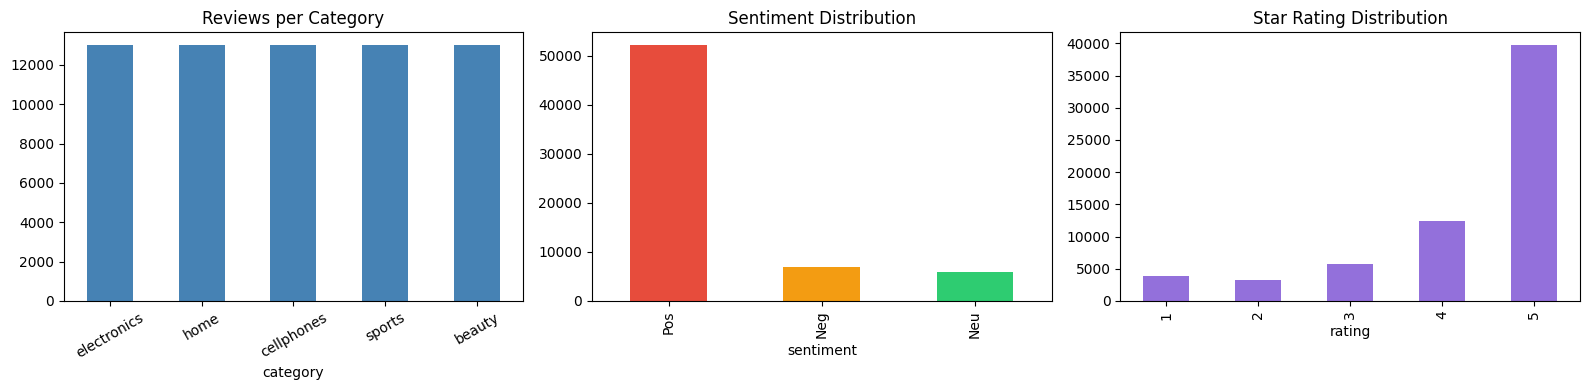

Plot saved to results/data_distribution.png


In [3]:
# ================================================================
# CELL 3 — Build Dataset Subset (30k-45k samples)
# ================================================================

def build_review_df(raw_data, max_per_cat, min_words):
    """Extract relevant fields and build a balanced DataFrame."""
    all_rows = []
    for cat, records in raw_data.items():
        count = 0
        random.shuffle(records)
        for r in records:
            if count >= max_per_cat:
                break
            # Required fields
            text = r.get("reviewText", "") or ""
            rating = r.get("overall", None)
            if not text or rating is None:
                continue
            # Minimum length filter
            if len(text.split()) < min_words:
                continue
            # Derived feature: verified purchase (1 = verified, 0 = not)
            verified = int(bool(r.get("verified", False)))
            # Optional: summary for decoder targets
            summary = r.get("summary", "") or ""
            all_rows.append({
                "category":  cat,
                "text":      text,
                "rating":    int(rating),
                "sentiment": SENTIMENT_MAP[int(rating)],
                "verified":  verified,
                "summary":   summary,
            })
            count += 1

    df = pd.DataFrame(all_rows)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return df


df = build_review_df(raw_data, CFG["MAX_PER_CAT"], CFG["MIN_WORDS"])
print(f"Dataset shape : {df.shape}")
print(f"\nCategory distribution:")
print(df["category"].value_counts())
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts().sort_index().rename({0:"Negative",1:"Neutral",2:"Positive"}))
print(f"\nVerified purchase distribution:")
print(df["verified"].value_counts())
print(f"\nRating distribution:")
print(df["rating"].value_counts().sort_index())

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["category"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Reviews per Category"); axes[0].tick_params(axis="x", rotation=30)

df["sentiment"].map({0:"Neg", 1:"Neu", 2:"Pos"}).value_counts().plot(
    kind="bar", ax=axes[1], color=["#e74c3c","#f39c12","#2ecc71"])
axes[1].set_title("Sentiment Distribution")

df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="mediumpurple")
axes[2].set_title("Star Rating Distribution")

plt.tight_layout()
plt.savefig("results/data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/data_distribution.png")


In [4]:
# ================================================================
# CELL 4 — Train / Validation / Test Split (70 / 15 / 15)
# ================================================================
n = len(df)
n_train = int(n * CFG["TRAIN_RATIO"])
n_val   = int(n * CFG["VAL_RATIO"])
n_test  = n - n_train - n_val

df_train = df.iloc[:n_train].reset_index(drop=True)
df_val   = df.iloc[n_train:n_train + n_val].reset_index(drop=True)
df_test  = df.iloc[n_train + n_val:].reset_index(drop=True)

print(f"Train : {len(df_train):,} ({len(df_train)/n*100:.1f}%)")
print(f"Val   : {len(df_val):,}   ({len(df_val)/n*100:.1f}%)")
print(f"Test  : {len(df_test):,}  ({len(df_test)/n*100:.1f}%)")

# Save splits for reproducibility
df_train.to_csv("results/train_split.csv", index=False)
df_val.to_csv("results/val_split.csv", index=False)
df_test.to_csv("results/test_split.csv", index=False)
print("\nSplits saved to results/")


Train : 45,500 (70.0%)
Val   : 9,750   (15.0%)
Test  : 9,750  (15.0%)

Splits saved to results/


## Step 2 — Preprocessing Pipeline

Custom pipeline (no external tokenizer libraries):
1. **Text cleaning** — lowercase, remove HTML, normalise whitespace  
2. **Word tokenisation** — simple regex split  
3. **Vocabulary construction** — from training data only  
4. **Numericalization** — token → integer index  
5. **Padding / Truncation** — fixed `MAX_SEQ_LEN`  
6. **[CLS] token prepending** — for encoder classification  


In [5]:
# ================================================================
# CELL 5 — Text Cleaning
# ================================================================
_HTML_RE   = re.compile(r"<[^>]+>")
_URL_RE    = re.compile(r"https?://\S+|www\.\S+")
_MULTI_SP  = re.compile(r"\s+")
_KEEP_CHAR = re.compile(r"[^a-z0-9\s'\.,!?\-]")

def clean_text(text: str) -> str:
    """Lowercase, strip HTML/URLs, remove unwanted chars, normalise whitespace."""
    text = text.lower()
    text = _HTML_RE.sub(" ", text)
    text = _URL_RE.sub(" ", text)
    text = _KEEP_CHAR.sub(" ", text)
    text = _MULTI_SP.sub(" ", text)
    return text.strip()

# Apply cleaning
df_train["clean"] = df_train["text"].apply(clean_text)
df_val["clean"]   = df_val["text"].apply(clean_text)
df_test["clean"]  = df_test["text"].apply(clean_text)

# Quick sanity check
print("Sample original :", df_train["text"].iloc[0][:120])
print("Sample cleaned  :", df_train["clean"].iloc[0][:120])


Sample original : I had one of this kind before, so it's not a bout the quality of the lens but the one from &#34;gray market&#34;.So far 
Sample cleaned  : i had one of this kind before, so it's not a bout the quality of the lens but the one from 34 gray market 34 .so far so 


In [6]:
# ================================================================
# CELL 6 — Tokeniser & Vocabulary Builder
# ================================================================

def simple_tokenize(text: str):
    """Split on whitespace / punctuation boundaries."""
    # Insert spaces around punctuation first
    text = re.sub(r"([.,!?\-])", r" \1 ", text)
    tokens = text.split()
    return tokens


class Vocabulary:
    """Maps tokens <-> integer indices. Built from training corpus only."""

    def __init__(self, pad, unk, cls_tok, bos, eos, sep):
        self.specials = [pad, unk, cls_tok, bos, eos, sep]
        self.pad_idx = 0
        self.unk_idx = 1
        self.cls_idx = 2
        self.bos_idx = 3
        self.eos_idx = 4
        self.sep_idx = 5
        self.token2idx = {t: i for i, t in enumerate(self.specials)}
        self.idx2token = {i: t for t, i in self.token2idx.items()}

    def build(self, texts, max_vocab):
        """Count tokens across all training texts and keep top-N."""
        counter = Counter()
        for text in tqdm(texts, desc="Building vocab"):
            counter.update(simple_tokenize(text))
        # Keep most frequent tokens
        for token, _ in counter.most_common(max_vocab - len(self.specials)):
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token
        print(f"Vocabulary size: {len(self.token2idx):,}")

    def encode(self, text, max_len, add_cls=True):
        """Tokenise → numericalize → truncate → pad."""
        tokens = simple_tokenize(text)
        # Reserve 1 slot for [CLS] if needed
        cap = max_len - (1 if add_cls else 0)
        tokens = tokens[:cap]
        ids = [self.token2idx.get(t, self.unk_idx) for t in tokens]
        if add_cls:
            ids = [self.cls_idx] + ids
        # Pad
        pad_len = max_len - len(ids)
        ids = ids + [self.pad_idx] * pad_len
        return ids  # length == max_len

    def decode(self, ids):
        return " ".join(
            self.idx2token.get(i, self.specials[1])
            for i in ids
            if i not in (self.pad_idx,)
        )

    def __len__(self):
        return len(self.token2idx)


# Build vocab from TRAINING data only
vocab = Vocabulary(
    pad=CFG["PAD"], unk=CFG["UNK"], cls_tok=CFG["CLS"],
    bos=CFG["BOS"], eos=CFG["EOS"], sep=CFG["SEP"],
)
vocab.build(df_train["clean"].tolist(), max_vocab=CFG["VOCAB_SIZE"])

# Persist vocabulary
with open("models/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
print("Vocabulary saved to models/vocab.pkl")


Building vocab:   0%|          | 0/45500 [00:00<?, ?it/s]

Vocabulary size: 15,000
Vocabulary saved to models/vocab.pkl


In [7]:
# ================================================================
# CELL 7 — PyTorch Datasets & DataLoaders (Encoder)
# ================================================================

class ReviewDataset(Dataset):
    """Returns (token_ids, attention_mask, sentiment_label, verified_label)."""

    def __init__(self, df, vocab, max_len):
        self.data     = df.reset_index(drop=True)
        self.vocab    = vocab
        self.max_len  = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        ids   = self.vocab.encode(row["clean"], self.max_len, add_cls=True)
        mask  = [1 if i != self.vocab.pad_idx else 0 for i in ids]
        return {
            "input_ids":   torch.tensor(ids,           dtype=torch.long),
            "attn_mask":   torch.tensor(mask,          dtype=torch.long),
            "sentiment":   torch.tensor(row["sentiment"], dtype=torch.long),
            "verified":    torch.tensor(row["verified"],  dtype=torch.long),
        }


enc_train_ds = ReviewDataset(df_train, vocab, CFG["MAX_SEQ_LEN"])
enc_val_ds   = ReviewDataset(df_val,   vocab, CFG["MAX_SEQ_LEN"])
enc_test_ds  = ReviewDataset(df_test,  vocab, CFG["MAX_SEQ_LEN"])

enc_train_dl = DataLoader(enc_train_ds, batch_size=CFG["ENC_BATCH"], shuffle=True,  num_workers=0, pin_memory=True)
enc_val_dl   = DataLoader(enc_val_ds,   batch_size=CFG["ENC_BATCH"], shuffle=False, num_workers=0)
enc_test_dl  = DataLoader(enc_test_ds,  batch_size=CFG["ENC_BATCH"], shuffle=False, num_workers=0)

print(f"Train batches: {len(enc_train_dl)}")
print(f"Val   batches: {len(enc_val_dl)}")
print(f"Test  batches: {len(enc_test_dl)}")


Train batches: 711
Val   batches: 153
Test  batches: 153


## Part A — Encoder-only Transformer (from scratch)

No `nn.Transformer`, `nn.MultiheadAttention`, or `nn.TransformerEncoder` used.

Architecture:
- **Token Embedding** + **Sinusoidal Positional Encoding**
- **N × Encoder Blocks**: LayerNorm → Multi-Head Self-Attention → Residual → LayerNorm → FFN → Residual
- **[CLS] pooling** → two task heads (Sentiment 3-class, Verified 2-class)


In [8]:
# ================================================================
# CELL 8 — Positional Encoding
# ================================================================

class PositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)        # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10_000.0) / d_model)
        )                                                                      # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                                                   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [9]:
# ================================================================
# CELL 9 — Scaled Dot-Product Attention & Multi-Head Attention
#            (from scratch — nn.MultiheadAttention NOT used)
# ================================================================

class MultiHeadSelfAttention(nn.Module):
    """
    Implements multi-head attention from scratch.

    Steps:
      1. Project input to Q, K, V using separate Linear layers.
      2. Split into n_heads along the embedding dimension.
      3. Compute scaled dot-product attention per head.
      4. Concatenate heads; project through output linear.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads   # dimension per head

        # Separate projection matrices for Q, K, V
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    # ── helper ───────────────────────────────────────────────────────────
    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, S, D) → (B, H, S, d_k)"""
        B, S, _ = x.shape
        return x.view(B, S, self.n_heads, self.d_k).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, H, S, d_k) → (B, S, D)"""
        B, H, S, dk = x.shape
        return x.transpose(1, 2).contiguous().view(B, S, H * dk)

    def _attention(self, Q, K, V, mask=None):
        """
        Scaled dot-product attention.
        Q, K, V : (B, H, S, d_k)
        mask    : (B, 1, 1, S) or (B, 1, S, S) — 1=keep, 0=mask
        Returns:
            context  (B, H, S, d_k)
            weights  (B, H, S, S)
        """
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale   # (B,H,S,S)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = self.attn_dropout(weights)
        context = torch.matmul(weights, V)
        return context, weights

    def forward(self, x: torch.Tensor, mask=None):
        """
        x    : (B, S, D)
        mask : padding mask (B, 1, 1, S)
        """
        Q = self._split_heads(self.W_q(x))
        K = self._split_heads(self.W_k(x))
        V = self._split_heads(self.W_v(x))

        context, attn_weights = self._attention(Q, K, V, mask)
        context = self._merge_heads(context)       # (B, S, D)
        return self.W_o(context), attn_weights


In [10]:
# ================================================================
# CELL 10 — Feed-Forward Sub-Layer & Encoder Block
# ================================================================

class FeedForward(nn.Module):
    """Position-wise two-layer FFN with GELU activation."""

    def __init__(self, d_model: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class EncoderBlock(nn.Module):
    """
    Pre-LayerNorm Encoder block (more stable training than post-LN):
      x → LN → MHSA → + residual → LN → FFN → + residual
    """

    def __init__(self, d_model: int, n_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ffn  = FeedForward(d_model, ffn_dim, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # ── Self-attention sub-layer ──────────────────────────────────
        residual = x
        x_norm   = self.ln1(x)
        attn_out, _ = self.attn(x_norm, mask)
        x        = residual + self.drop(attn_out)

        # ── Feed-forward sub-layer ────────────────────────────────────
        residual = x
        x_norm   = self.ln2(x)
        x        = residual + self.ffn(x_norm)
        return x


In [11]:
# ================================================================
# CELL 11 — Full Encoder + Multi-Task Classification Heads
# ================================================================

class TransformerEncoderModel(nn.Module):
    """
    Encoder-only Transformer for multi-task classification.

    Tasks:
      1. Sentiment      (3-class: Negative / Neutral / Positive)
      2. Verified Purch.(2-class: Not-verified / Verified)

    The [CLS] token embedding is used for both task heads.
    The final [CLS] embedding is also saved as the review representation
    for downstream retrieval in Part B.
    """

    def __init__(self, vocab_size, d_model, n_heads, n_layers,
                 ffn_dim, max_len, dropout, num_sentiment=3, num_verified=2):
        super().__init__()
        self.d_model = d_model

        # ── Embeddings ────────────────────────────────────────────────
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        # ── Encoder stack ─────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.ln_out = nn.LayerNorm(d_model)

        # ── Task heads ────────────────────────────────────────────────
        self.sentiment_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_sentiment),
        )
        self.verified_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_verified),
        )

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_padding_mask(self, attn_mask):
        """
        attn_mask : (B, S)  1=real token, 0=padding
        returns   : (B, 1, 1, S)  broadcastable over (B, H, S, S)
        """
        return attn_mask.unsqueeze(1).unsqueeze(2)

    def encode(self, input_ids, attn_mask):
        """Forward through embedding + encoder blocks → (B, S, D)."""
        mask = self.make_padding_mask(attn_mask)
        x    = self.token_emb(input_ids) * math.sqrt(self.d_model)
        x    = self.pos_enc(x)
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln_out(x)
        return x

    def forward(self, input_ids, attn_mask):
        hidden = self.encode(input_ids, attn_mask)  # (B, S, D)
        cls_h  = hidden[:, 0, :]                    # [CLS] token

        sentiment_logits = self.sentiment_head(cls_h)
        verified_logits  = self.verified_head(cls_h)
        return sentiment_logits, verified_logits, cls_h


# Instantiate
encoder = TransformerEncoderModel(
    vocab_size   = len(vocab),
    d_model      = CFG["ENC_D_MODEL"],
    n_heads      = CFG["ENC_N_HEADS"],
    n_layers     = CFG["ENC_N_LAYERS"],
    ffn_dim      = CFG["ENC_FFN_DIM"],
    max_len      = CFG["MAX_SEQ_LEN"] + 10,
    dropout      = CFG["ENC_DROPOUT"],
).to(DEVICE)

total_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Encoder parameters: {total_params:,}")


Encoder parameters: 2,333,381


## Part A — Training the Encoder

Joint training with combined loss: `L = L_sentiment + 0.5 * L_verified`

In [12]:
# ================================================================
# CELL 12 — Encoder Training Loop
# ================================================================

def train_encoder_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_sent_loss = total_ver_loss = 0
    all_sent_pred, all_sent_true = [], []
    all_ver_pred,  all_ver_true  = [], []

    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attn_mask"].to(DEVICE)
        sent_lbl  = batch["sentiment"].to(DEVICE)
        ver_lbl   = batch["verified"].to(DEVICE)

        optimizer.zero_grad()
        sent_logits, ver_logits, _ = model(input_ids, attn_mask)

        loss_sent = criterion(sent_logits, sent_lbl)
        loss_ver  = criterion(ver_logits,  ver_lbl)
        loss      = loss_sent + 0.5 * loss_ver   # weighted combined loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss      += loss.item()
        total_sent_loss += loss_sent.item()
        total_ver_loss  += loss_ver.item()

        all_sent_pred.extend(sent_logits.argmax(-1).cpu().tolist())
        all_sent_true.extend(sent_lbl.cpu().tolist())
        all_ver_pred.extend(ver_logits.argmax(-1).cpu().tolist())
        all_ver_true.extend(ver_lbl.cpu().tolist())

    n = len(loader)
    return {
        "loss":      total_loss / n,
        "sent_loss": total_sent_loss / n,
        "ver_loss":  total_ver_loss / n,
        "sent_acc":  accuracy_score(all_sent_true, all_sent_pred),
        "ver_acc":   accuracy_score(all_ver_true,  all_ver_pred),
    }


@torch.no_grad()
def eval_encoder(model, loader):
    model.eval()
    total_loss = 0
    all_sent_pred, all_sent_true = [], []
    all_ver_pred,  all_ver_true  = [], []
    criterion = nn.CrossEntropyLoss()

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attn_mask"].to(DEVICE)
        sent_lbl  = batch["sentiment"].to(DEVICE)
        ver_lbl   = batch["verified"].to(DEVICE)

        sent_logits, ver_logits, _ = model(input_ids, attn_mask)

        loss = criterion(sent_logits, sent_lbl) + 0.5 * criterion(ver_logits, ver_lbl)
        total_loss += loss.item()

        all_sent_pred.extend(sent_logits.argmax(-1).cpu().tolist())
        all_sent_true.extend(sent_lbl.cpu().tolist())
        all_ver_pred.extend(ver_logits.argmax(-1).cpu().tolist())
        all_ver_true.extend(ver_lbl.cpu().tolist())

    n = len(loader)
    return {
        "loss":     total_loss / n,
        "sent_acc": accuracy_score(all_sent_true, all_sent_pred),
        "ver_acc":  accuracy_score(all_ver_true,  all_ver_pred),
        "sent_f1":  f1_score(all_sent_true, all_sent_pred, average="macro"),
        "ver_f1":   f1_score(all_ver_true,  all_ver_pred,  average="macro"),
        "sent_pred": all_sent_pred,
        "sent_true": all_sent_true,
        "ver_pred":  all_ver_pred,
        "ver_true":  all_ver_true,
    }


# ── Optimiser & Scheduler ────────────────────────────────────────────────
optimizer = AdamW(encoder.parameters(), lr=CFG["ENC_LR"], weight_decay=CFG["ENC_WD"])
n_steps   = CFG["ENC_EPOCHS"] * len(enc_train_dl)
scheduler = CosineAnnealingLR(optimizer, T_max=n_steps, eta_min=1e-6)

print(f"Training encoder for {CFG['ENC_EPOCHS']} epochs ...")
print(f"Total optimiser steps: {n_steps:,}")


Training encoder for 10 epochs ...
Total optimiser steps: 7,110


In [14]:
# ================================================================
# CELL 13 — Run Encoder Training
# ================================================================

enc_history = {"train": [], "val": []}
best_val_loss = float("inf")

for epoch in range(1, CFG["ENC_EPOCHS"] + 1):
    t0 = time.time()
    train_metrics = train_encoder_epoch(encoder, enc_train_dl, optimizer, scheduler)
    val_metrics   = eval_encoder(encoder, enc_val_dl)
    elapsed = time.time() - t0

    enc_history["train"].append(train_metrics)
    enc_history["val"].append(val_metrics)

    # Save best model
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(encoder.state_dict(), "models/encoder_best.pt")

    print(
        f"Epoch {epoch:02d}/{CFG['ENC_EPOCHS']} | "
        f"TrainLoss={train_metrics['loss']:.4f} | "
        f"ValLoss={val_metrics['loss']:.4f} | "
        f"SentAcc={val_metrics['sent_acc']:.3f} | "
        f"VerAcc={val_metrics['ver_acc']:.3f} | "
        f"SentF1={val_metrics['sent_f1']:.3f} | "
        f"Time={elapsed:.1f}s"
    )

print(f"\nBest validation loss: {best_val_loss:.4f}")
print("Best encoder weights saved to models/encoder_best.pt")


Training:   0%|          | 0/711 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/153 [00:00<?, ?it/s]

Epoch 01/10 | TrainLoss=0.5297 | ValLoss=0.4437 | SentAcc=0.841 | VerAcc=1.000 | SentF1=0.492 | Time=1182.5s


Training:   0%|          | 0/711 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/153 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/153 [00:00<?, ?it/s]

Epoch 09/10 | TrainLoss=0.0477 | ValLoss=1.1833 | SentAcc=0.807 | VerAcc=1.000 | SentF1=0.546 | Time=1378.9s


Training:   0%|          | 0/711 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/153 [00:00<?, ?it/s]

Epoch 10/10 | TrainLoss=0.0454 | ValLoss=1.1907 | SentAcc=0.809 | VerAcc=1.000 | SentF1=0.548 | Time=1949.5s

Best validation loss: 0.4437
Best encoder weights saved to models/encoder_best.pt


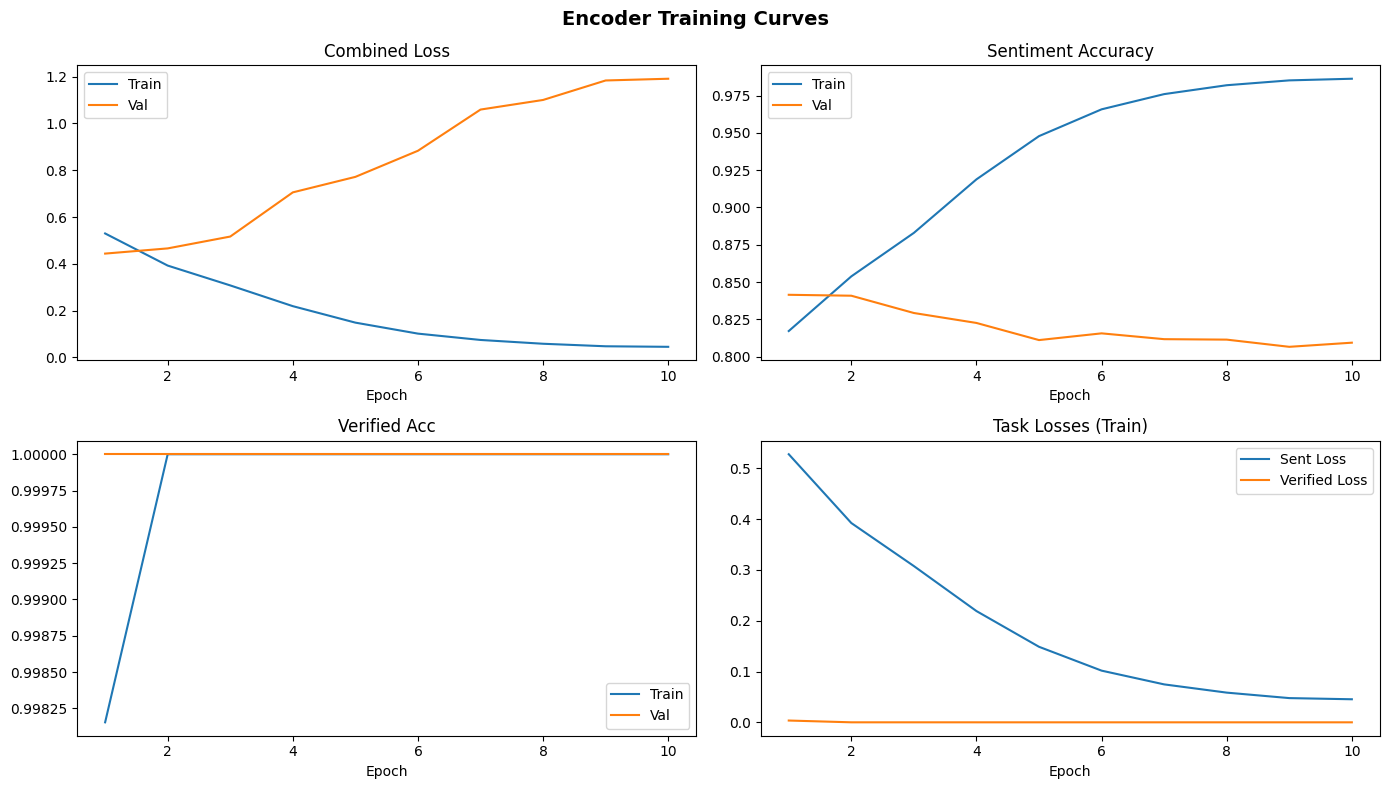

In [15]:
# ================================================================
# CELL 14 — Learning Curves
# ================================================================

epochs_range = range(1, CFG["ENC_EPOCHS"] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Encoder Training Curves", fontsize=14, fontweight="bold")

# ── Loss ──────────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_range, [m["loss"] for m in enc_history["train"]], label="Train")
axes[0, 0].plot(epochs_range, [m["loss"] for m in enc_history["val"]],   label="Val")
axes[0, 0].set_title("Combined Loss"); axes[0, 0].set_xlabel("Epoch"); axes[0, 0].legend()

# ── Sentiment Accuracy ────────────────────────────────────────────────────
axes[0, 1].plot(epochs_range, [m["sent_acc"] for m in enc_history["train"]], label="Train")
axes[0, 1].plot(epochs_range, [m["sent_acc"] for m in enc_history["val"]],   label="Val")
axes[0, 1].set_title("Sentiment Accuracy"); axes[0, 1].set_xlabel("Epoch"); axes[0, 1].legend()

# ── Verified Accuracy ─────────────────────────────────────────────────────
axes[1, 0].plot(epochs_range, [m["ver_acc"] for m in enc_history["train"]], label="Train")
axes[1, 0].plot(epochs_range, [m["ver_acc"] for m in enc_history["val"]],   label="Val")
axes[1, 0].set_title("Verified Acc"); axes[1, 0].set_xlabel("Epoch"); axes[1, 0].legend()

# ── Sent loss component ───────────────────────────────────────────────────
axes[1, 1].plot(epochs_range, [m["sent_loss"] for m in enc_history["train"]], label="Sent Loss")
axes[1, 1].plot(epochs_range, [m["ver_loss"]  for m in enc_history["train"]], label="Verified Loss")
axes[1, 1].set_title("Task Losses (Train)"); axes[1, 1].set_xlabel("Epoch"); axes[1, 1].legend()

plt.tight_layout()
plt.savefig("results/encoder_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


Evaluating:   0%|          | 0/153 [00:00<?, ?it/s]

ENCODER — TEST SET RESULTS

[Task 1] Sentiment Classification
  Accuracy : 0.8351
  Macro-F1 : 0.4907
              precision    recall  f1-score   support

    Negative       0.63      0.47      0.54      1068
     Neutral       0.42      0.01      0.02       889
    Positive       0.85      0.98      0.91      7793

    accuracy                           0.84      9750
   macro avg       0.63      0.49      0.49      9750
weighted avg       0.79      0.84      0.79      9750


[Task 2] Verified Purchase Prediction
  Accuracy : 1.0000
  Macro-F1 : 1.0000
              precision    recall  f1-score   support

Not-Verified       1.00      1.00      1.00      9750
    Verified       0.00      0.00      0.00         0

    accuracy                           1.00      9750
   macro avg       0.50      0.50      0.50      9750
weighted avg       1.00      1.00      1.00      9750



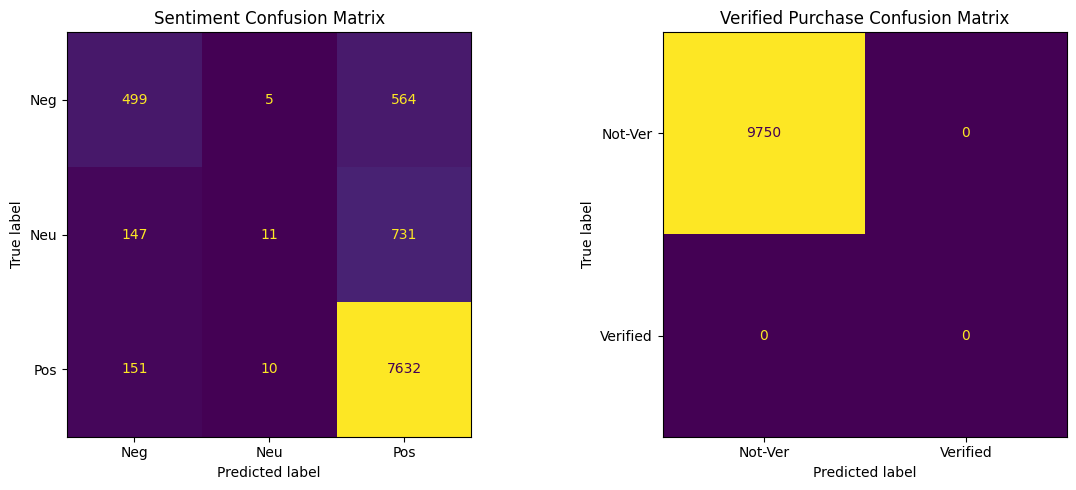

In [15]:
# ================================================================
# CELL 15 — Encoder Test Evaluation & Confusion Matrices
# ================================================================

# Load best weights
encoder.load_state_dict(torch.load("models/encoder_best.pt", map_location=DEVICE))
test_metrics = eval_encoder(encoder, enc_test_dl)

print("=" * 60)
print("ENCODER — TEST SET RESULTS")
print("=" * 60)
print(f"\n[Task 1] Sentiment Classification")
print(f"  Accuracy : {test_metrics['sent_acc']:.4f}")
print(f"  Macro-F1 : {test_metrics['sent_f1']:.4f}")
print(classification_report(
    test_metrics["sent_true"], test_metrics["sent_pred"],
    labels=[0, 1, 2], target_names=["Negative", "Neutral", "Positive"], zero_division=0
))

print(f"\n[Task 2] Verified Purchase Prediction")
print(f"  Accuracy : {test_metrics['ver_acc']:.4f}")
print(f"  Macro-F1 : {test_metrics['ver_f1']:.4f}")
print(classification_report(
    test_metrics["ver_true"], test_metrics["ver_pred"],
    labels=[0, 1], target_names=["Not-Verified", "Verified"], zero_division=0
))

# Save metrics
import json
with open("results/encoder_test_metrics.json", "w") as f:
    json.dump({k: v for k, v in test_metrics.items()
               if k not in ("sent_pred","sent_true","ver_pred","ver_true")}, f, indent=2)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(test_metrics["sent_true"], test_metrics["sent_pred"], labels=[0, 1, 2]),
    display_labels=["Neg","Neu","Pos"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Sentiment Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix(test_metrics["ver_true"], test_metrics["ver_pred"], labels=[0, 1]),
    display_labels=["Not-Ver","Verified"]
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Verified Purchase Confusion Matrix")

plt.tight_layout()
plt.savefig("results/encoder_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## Part A — Extract & Save Training Embeddings

The `[CLS]` vector for every training review is extracted and stored for retrieval in Part B.

In [16]:
# ================================================================
# CELL 16 — Extract & Save Training Set Embeddings
# ================================================================

@torch.no_grad()
def extract_embeddings(model, loader):
    """Return CLS embeddings for all samples in loader."""
    model.eval()
    all_embs = []
    for batch in tqdm(loader, desc="Extracting embeddings"):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attn_mask"].to(DEVICE)
        _, _, cls_h = model(input_ids, attn_mask)
        all_embs.append(cls_h.cpu().numpy())
    return np.vstack(all_embs)


train_embeddings = extract_embeddings(encoder, enc_train_dl)
print(f"Train embeddings shape : {train_embeddings.shape}")

# Save embeddings + metadata (include 'clean' column needed for decoder dataset building)
np.save("results/train_embeddings.npy", train_embeddings)
df_train[["category","text","clean","sentiment","verified","summary"]].to_csv(
    "results/train_metadata.csv", index=False
)
print("Embeddings saved to results/train_embeddings.npy")
print("Metadata  saved to results/train_metadata.csv (includes 'clean' column)")


Extracting embeddings:   0%|          | 0/711 [00:00<?, ?it/s]

Train embeddings shape : (45500, 128)
Embeddings saved to results/train_embeddings.npy
Metadata  saved to results/train_metadata.csv (includes 'clean' column)


## Part B — Retrieval Module

1. Load stored train embeddings  
2. For a test-set query, compute cosine similarity against all training embeddings  
3. Return top-k most similar training reviews  
4. Analyse retrieval quality with examples  


In [17]:
# ================================================================
# CELL 17 — Retrieval Module
# ================================================================

class RetrievalIndex:
    """
    Flat cosine-similarity retrieval index over stored embeddings.

    Cosine similarity chosen because it is scale-invariant (magnitude of
    the CLS vector is not semantically meaningful; direction is).
    """

    def __init__(self, embeddings: np.ndarray, metadata_df: pd.DataFrame):
        # L2-normalise so dot product == cosine similarity
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8
        self.embs  = (embeddings / norms).astype(np.float32)
        self.meta  = metadata_df.reset_index(drop=True)

    def query(self, q_emb: np.ndarray, top_k: int = 3):
        """
        q_emb  : (D,) query embedding
        Returns: list of dicts with keys {text, sentiment, verified, similarity}
        """
        # Normalise query
        q = q_emb / (np.linalg.norm(q_emb) + 1e-8)
        # Dot product = cosine similarity (both normalised)
        scores   = self.embs @ q                    # (N,)
        top_idxs = np.argsort(scores)[::-1][:top_k]
        results  = []
        for idx in top_idxs:
            row = self.meta.iloc[idx]
            results.append({
                "text":       row["text"],
                "sentiment":  int(row["sentiment"]),
                "verified":   int(row["verified"]),
                "similarity": float(scores[idx]),
            })
        return results


# Load stored embeddings
train_embs_np = np.load("results/train_embeddings.npy")
train_meta_df = pd.read_csv("results/train_metadata.csv")

retrieval_index = RetrievalIndex(train_embs_np, train_meta_df)
print(f"Retrieval index built over {len(train_meta_df):,} training reviews.")
print(f"Top-k = {CFG['TOP_K']}")


Retrieval index built over 45,500 training reviews.
Top-k = 3


In [18]:
# ================================================================
# CELL 18 — Retrieval Quality Analysis
# ================================================================

def get_query_embedding(model, vocab, text, max_len):
    """Encode a single review and return its CLS embedding."""
    model.eval()
    ids  = vocab.encode(clean_text(text), max_len, add_cls=True)
    mask = [1 if i != vocab.pad_idx else 0 for i in ids]
    ids_t  = torch.tensor([ids],  dtype=torch.long).to(DEVICE)
    mask_t = torch.tensor([mask], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        _, _, cls_h = model(ids_t, mask_t)
    return cls_h.squeeze(0).cpu().numpy()


# ── Show 5 retrieval examples ─────────────────────────────────────────────
print("RETRIEVAL QUALITY EXAMPLES")
print("=" * 70)

for i in range(5):
    query_row = df_test.iloc[i]
    q_emb     = get_query_embedding(encoder, vocab, query_row["text"], CFG["MAX_SEQ_LEN"])
    results   = retrieval_index.query(q_emb, top_k=CFG["TOP_K"])

    print(f"\n--- Query {i+1} ---")
    print(f"Text     : {query_row['text'][:120]}...")
    print(f"Sentiment: {SENTIMENT_STR[query_row['sentiment']]} | Verified: {bool(query_row['verified'])}")
    print(f"\nTop-{CFG['TOP_K']} Retrieved:")
    for j, r in enumerate(results, 1):
        print(f"  [{j}] sim={r['similarity']:.3f} | {SENTIMENT_STR[r['sentiment']]} | "
              f"{r['text'][:80]}...")
    print("-" * 70)


# ── Effect of k on diversity ──────────────────────────────────────────────
q_emb_demo = get_query_embedding(encoder, vocab, df_test.iloc[0]["text"], CFG["MAX_SEQ_LEN"])
for k in [1, 3, 5, 10]:
    hits = retrieval_index.query(q_emb_demo, top_k=k)
    sents = [SENTIMENT_STR[r["sentiment"]] for r in hits]
    sims  = [r["similarity"] for r in hits]
    print(f"k={k:2d} | avg_sim={np.mean(sims):.3f} | sentiments={sents}")


RETRIEVAL QUALITY EXAMPLES

--- Query 1 ---
Text     : they seem ok, they sent a size too big but I won't use them very often & they will do....
Sentiment: Neutral | Verified: False

Top-3 Retrieved:
  [1] sim=0.997 | Positive | It came quickly and is quite nice to be able to measure from above. Not a single...
  [2] sim=0.995 | Negative | For being one of Jawbone's elite earpieces, I was very disappointed in this prod...
  [3] sim=0.994 | Positive | I wanted a set of cheap headphones for gaming when the wife's asleep.  These fit...
----------------------------------------------------------------------

--- Query 2 ---
Text     : This stuff is awesome. I have sensitive skin and this really helps to exfoliate but is gentle on my skin....
Sentiment: Positive | Verified: False

Top-3 Retrieved:
  [1] sim=0.998 | Positive | They are cool enough for him.  He loves the sound cancelling (maybe because he c...
  [2] sim=0.998 | Positive | This is the first lens I bought for my DSLR. I have got

## Part C — Decoder-only Transformer (RAG Explanation Generation)

**Input template:**
```
<BOS> [REVIEW] {review_text} [SENTIMENT] {Positive/Neutral/Negative} [VERIFIED] {yes/no} [CONTEXT] {retrieved_text_1} ... <SEP> [EXPLANATION] {target_explanation} <EOS>
```
The model is trained to predict tokens in the `[EXPLANATION]` portion given all preceding context. At inference time, generation stops at `<EOS>` or max-length.


In [19]:
# ================================================================
# CELL 19 — Build Decoder Training Data (Explanation Templates)
# ================================================================

SENT_WORD = {0: "negative", 1: "neutral", 2: "positive"}
VER_WORD  = {0: "not verified", 1: "verified"}

def make_explanation(row):
    """
    Derive a 1-2 sentence explanation from available review fields.
    Uses the Amazon "summary" if available, otherwise builds from templates.
    """
    s   = SENT_WORD[row["sentiment"]]
    ver = VER_WORD[int(row["verified"])]
    # Use review summary if non-empty and meaningful
    if isinstance(row.get("summary", ""), str) and len(str(row.get("summary","")).split()) >= 3:
        summary = str(row["summary"]).strip().strip(".")
        return f"This is a {s} review from a {ver} purchaser. {summary}."
    # Fallback template
    cat = str(row.get("category","product")).replace("_"," ")
    return (f"This is a {s} review of a {cat} item from a {ver} purchaser. "
            f"The reviewer's experience reflects a {s} overall impression.")


def build_decoder_sequence(row, retrieved, vocab, max_len):
    """
    Combine review, sentiment, verified, retrieved context, and explanation
    into a single token sequence for language modelling.
    
    Format:
      <BOS> [REVIEW] review_tokens [SENTIMENT] sent [VERIFIED] ver
            [CONTEXT] ctx_tokens [EXPLANATION] expl_tokens <EOS>
    """
    explanation = make_explanation(row)

    # Build raw text prompt
    ctx_texts = " ".join([r["text"][:80] for r in retrieved])
    full_text = (
        f"[REVIEW] {row['clean']} "
        f"[SENTIMENT] {SENT_WORD[row['sentiment']]} "
        f"[VERIFIED] {VER_WORD[int(row['verified'])]} "
        f"[CONTEXT] {ctx_texts} "
        f"[EXPLANATION] {explanation}"
    )
    ids = [vocab.bos_idx] + vocab.encode(clean_text(full_text), max_len - 2, add_cls=False)
    ids = ids[:max_len - 1] + [vocab.eos_idx]
    # Pad
    ids = ids + [vocab.pad_idx] * max(0, max_len - len(ids))
    return ids[:max_len]


print("Building decoder training sequences (this may take a few minutes)...")

# We need embeddings for the training set to do retrieval at training time
# (self-retrieval during training — exclude the query itself at inference)
def build_decoder_dataset(df, df_ref, embs_ref, vocab, max_len, top_k, split_name):
    """Build decoder sequences for a split."""
    index = RetrievalIndex(embs_ref, df_ref)
    sequences = []
    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"Building {split_name} decoder data"):
        q_emb = get_query_embedding(encoder, vocab, row["text"], CFG["MAX_SEQ_LEN"])
        retrieved = index.query(q_emb, top_k=top_k)
        seq = build_decoder_sequence(row, retrieved, vocab, max_len)
        sequences.append(seq)
    return np.array(sequences, dtype=np.int32)


# train_meta_df already has 'clean' column (saved in Cell 16)
# Verify it exists, otherwise recompute
if "clean" not in train_meta_df.columns:
    train_meta_df["clean"] = df_train["clean"].values[:len(train_meta_df)]
    print("Warning: 'clean' column was missing from metadata — recomputed from df_train.")

# Build for val & test first (smaller)
dec_val_seqs  = build_decoder_dataset(
    df_val, train_meta_df,
    train_embs_np, vocab, CFG["DEC_MAX_SEQ"], CFG["TOP_K"], "val")

dec_test_seqs = build_decoder_dataset(
    df_test, train_meta_df,
    train_embs_np, vocab, CFG["DEC_MAX_SEQ"], CFG["TOP_K"], "test")

# Build train sequences
dec_train_seqs = build_decoder_dataset(
    df_train, train_meta_df,
    train_embs_np, vocab, CFG["DEC_MAX_SEQ"], CFG["TOP_K"], "train")

print(f"\nDecoder sequences:")
print(f"  Train : {dec_train_seqs.shape}")
print(f"  Val   : {dec_val_seqs.shape}")
print(f"  Test  : {dec_test_seqs.shape}")

np.save("results/dec_train_seqs.npy", dec_train_seqs)
np.save("results/dec_val_seqs.npy",   dec_val_seqs)
np.save("results/dec_test_seqs.npy",  dec_test_seqs)
print("Decoder sequences saved to results/")


Building decoder training sequences (this may take a few minutes)...


Building val decoder data:   0%|          | 0/9750 [00:00<?, ?it/s]

Building test decoder data:   0%|          | 0/9750 [00:00<?, ?it/s]

Building train decoder data:   0%|          | 0/45500 [00:00<?, ?it/s]


Decoder sequences:
  Train : (45500, 80)
  Val   : (9750, 80)
  Test  : (9750, 80)
Decoder sequences saved to results/


In [20]:
# ================================================================
# CELL 20 — Decoder Dataset & DataLoader
# ================================================================

class LanguageModelDataset(Dataset):
    """
    For language modelling: input = seq[:-1], target = seq[1:]
    Loss is computed only on non-padding positions.
    """

    def __init__(self, sequences: np.ndarray):
        self.seqs = sequences

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq    = torch.tensor(self.seqs[idx], dtype=torch.long)
        inp    = seq[:-1]
        target = seq[1:]
        return inp, target


dec_train_ds = LanguageModelDataset(dec_train_seqs)
dec_val_ds   = LanguageModelDataset(dec_val_seqs)
dec_test_ds  = LanguageModelDataset(dec_test_seqs)

dec_train_dl = DataLoader(dec_train_ds, batch_size=CFG["DEC_BATCH"], shuffle=True,  num_workers=0)
dec_val_dl   = DataLoader(dec_val_ds,   batch_size=CFG["DEC_BATCH"], shuffle=False, num_workers=0)
dec_test_dl  = DataLoader(dec_test_ds,  batch_size=CFG["DEC_BATCH"], shuffle=False, num_workers=0)

print(f"Decoder train batches: {len(dec_train_dl)}")
print(f"Decoder val   batches: {len(dec_val_dl)}")


Decoder train batches: 1422
Decoder val   batches: 305


## Part C — Decoder Architecture (from scratch)

Causal (masked) self-attention ensures the model cannot attend to future tokens.

In [21]:
# ================================================================
# CELL 21 — Causal Multi-Head Self-Attention (Decoder)
# ================================================================

class CausalMultiHeadAttention(nn.Module):
    """
    Multi-head self-attention with causal (autoregressive) mask.
    
    The causal mask is a lower-triangular boolean matrix:
      position i may only attend to positions j <= i.
    This enforces left-to-right generation during training and inference.

    IMPORTANT: nn.MultiheadAttention is NOT used — implemented from scratch.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

        self.attn_drop = nn.Dropout(dropout)
        self.scale     = math.sqrt(self.d_k)

    def _split(self, x):
        B, S, _ = x.shape
        return x.view(B, S, self.n_heads, self.d_k).transpose(1, 2)   # (B,H,S,dk)

    def _merge(self, x):
        B, H, S, dk = x.shape
        return x.transpose(1, 2).contiguous().view(B, S, H * dk)

    def _make_causal_mask(self, seq_len, device):
        """
        Lower-triangular mask of shape (1, 1, S, S).
        mask[i,j] = 1 if j <= i (can attend), 0 otherwise (blocked).
        """
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask.unsqueeze(0).unsqueeze(0)                           # (1,1,S,S)

    def forward(self, x):
        B, S, _ = x.shape
        Q = self._split(self.W_q(x))
        K = self._split(self.W_k(x))
        V = self._split(self.W_v(x))

        # ── Causal mask ──────────────────────────────────────────────
        causal_mask = self._make_causal_mask(S, x.device)              # (1,1,S,S)

        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale    # (B,H,S,S)
        scores  = scores.masked_fill(causal_mask == 0, float("-inf"))   # block future
        weights = F.softmax(scores, dim=-1)
        weights = self.attn_drop(weights)

        context = torch.matmul(weights, V)                              # (B,H,S,dk)
        context = self._merge(context)                                  # (B,S,D)
        return self.W_o(context)


class DecoderBlock(nn.Module):
    """
    Pre-LN Decoder block (causal self-attention only — no cross-attention
    because the retrieved context is prepended directly in the input sequence):
      x → LN → CausalMHSA → + residual → LN → FFN → + residual
    """

    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.attn = CausalMultiHeadAttention(d_model, n_heads, dropout)
        self.ffn  = FeedForward(d_model, ffn_dim, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # Causal self-attention
        residual = x
        x = residual + self.drop(self.attn(self.ln1(x)))
        # FFN
        residual = x
        x = residual + self.ffn(self.ln2(x))
        return x


class TransformerDecoderModel(nn.Module):
    """
    Decoder-only Transformer for autoregressive language modelling.
    
    Generates one token at a time conditioned on all previous tokens.
    RAG context is prepended to the input sequence.
    """

    def __init__(self, vocab_size, d_model, n_heads, n_layers, ffn_dim, max_len, dropout):
        super().__init__()
        self.d_model   = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.blocks    = nn.ModuleList([
            DecoderBlock(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.ln_out    = nn.LayerNorm(d_model)
        self.lm_head   = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding & output projection weights
        self.lm_head.weight = self.token_emb.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids):
        """
        input_ids : (B, S)
        returns   : logits (B, S, V)
        """
        x = self.token_emb(input_ids) * math.sqrt(self.d_model)
        x = self.pos_enc(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln_out(x)
        return self.lm_head(x)

    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens, eos_idx, temperature=0.9, top_k=40):
        """
        Autoregressive token-by-token generation.
        prompt_ids : (1, S_prompt) initial context
        Terminates when <EOS> is produced or max_new_tokens reached.
        """
        self.eval()
        ids = prompt_ids.clone()

        for _ in range(max_new_tokens):
            # Truncate to model max context if needed
            ctx = ids[:, -self.pos_enc.pe.size(1):]
            logits = self.forward(ctx)[:, -1, :]           # (1, V)

            # Temperature + top-k sampling
            logits = logits / max(temperature, 1e-6)
            if top_k > 0:
                topk_vals, _ = torch.topk(logits, top_k)
                thresh = topk_vals[:, -1].unsqueeze(-1)
                logits = logits.masked_fill(logits < thresh, float("-inf"))
            probs   = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)   # (1,1)
            ids     = torch.cat([ids, next_id], dim=1)

            if next_id.item() == eos_idx:
                break

        return ids


# Instantiate decoder
decoder = TransformerDecoderModel(
    vocab_size = len(vocab),
    d_model    = CFG["DEC_D_MODEL"],
    n_heads    = CFG["DEC_N_HEADS"],
    n_layers   = CFG["DEC_N_LAYERS"],
    ffn_dim    = CFG["DEC_FFN_DIM"],
    max_len    = CFG["DEC_MAX_SEQ"] + 10,
    dropout    = CFG["DEC_DROPOUT"],
).to(DEVICE)

total_dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder parameters: {total_dec_params:,}")


Decoder parameters: 2,184,448


## Part C — Decoder Training

In [22]:
# ================================================================
# CELL 22 — Decoder Training Loop
# ================================================================

def train_decoder_epoch(model, loader, optimizer):
    model.train()
    total_loss = total_tokens = 0
    criterion  = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")  # ignore PAD

    for inp, target in tqdm(loader, desc="Dec Train", leave=False):
        inp    = inp.to(DEVICE)
        target = target.to(DEVICE)

        optimizer.zero_grad()
        logits = model(inp)                          # (B, S, V)
        # Flatten for loss
        B, S, V = logits.shape
        loss   = criterion(logits.reshape(B * S, V), target.reshape(B * S))
        n_tok  = (target != 0).sum().item()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss   += loss.item()
        total_tokens += n_tok

    return total_loss / (total_tokens + 1e-8)


@torch.no_grad()
def eval_decoder(model, loader):
    model.eval()
    total_loss = total_tokens = 0
    criterion  = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")

    for inp, target in tqdm(loader, desc="Dec Eval", leave=False):
        inp    = inp.to(DEVICE)
        target = target.to(DEVICE)
        logits = model(inp)
        B, S, V = logits.shape
        loss   = criterion(logits.reshape(B * S, V), target.reshape(B * S))
        n_tok  = (target != 0).sum().item()
        total_loss   += loss.item()
        total_tokens += n_tok

    avg_loss  = total_loss / (total_tokens + 1e-8)
    perplexity = math.exp(min(avg_loss, 20))         # cap to avoid overflow
    return avg_loss, perplexity


# Optimiser (no scheduler needed for decoder — simpler setup)
dec_optimizer = AdamW(decoder.parameters(), lr=CFG["DEC_LR"], weight_decay=CFG["DEC_WD"])
dec_scheduler = CosineAnnealingLR(dec_optimizer, T_max=CFG["DEC_EPOCHS"])

dec_history = {"train_loss": [], "val_loss": [], "val_ppl": []}
best_dec_loss = float("inf")

print(f"Training decoder for {CFG['DEC_EPOCHS']} epochs ...")

for epoch in range(1, CFG["DEC_EPOCHS"] + 1):
    t0         = time.time()
    train_loss = train_decoder_epoch(decoder, dec_train_dl, dec_optimizer)
    val_loss, val_ppl = eval_decoder(decoder, dec_val_dl)
    dec_scheduler.step()
    elapsed    = time.time() - t0

    dec_history["train_loss"].append(train_loss)
    dec_history["val_loss"].append(val_loss)
    dec_history["val_ppl"].append(val_ppl)

    if val_loss < best_dec_loss:
        best_dec_loss = val_loss
        torch.save(decoder.state_dict(), "models/decoder_best.pt")

    print(
        f"Epoch {epoch:02d}/{CFG['DEC_EPOCHS']} | "
        f"TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | "
        f"ValPPL={val_ppl:.2f} | Time={elapsed:.1f}s"
    )

print(f"\nBest decoder val loss: {best_dec_loss:.4f}")
print("Best decoder weights saved to models/decoder_best.pt")


Training decoder for 8 epochs ...


Dec Train:   0%|          | 0/1422 [00:00<?, ?it/s]

Dec Eval:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 01/8 | TrainLoss=5.2161 | ValLoss=4.6263 | ValPPL=102.14 | Time=1311.6s


Dec Train:   0%|          | 0/1422 [00:00<?, ?it/s]

...

Dec Eval:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 07/8 | TrainLoss=4.0611 | ValLoss=4.0170 | ValPPL=55.54 | Time=1398.2s


Dec Train:   0%|          | 0/1422 [00:00<?, ?it/s]

Dec Eval:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 08/8 | TrainLoss=4.0447 | ValLoss=4.0133 | ValPPL=55.33 | Time=1206.4s

Best decoder val loss: 4.0133
Best decoder weights saved to models/decoder_best.pt


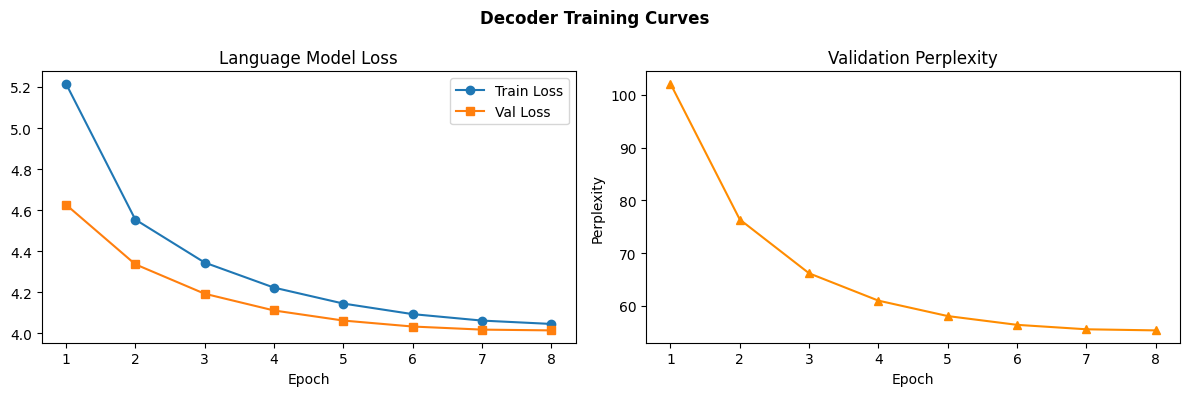

In [23]:
# ================================================================
# CELL 23 — Decoder Learning Curves
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Decoder Training Curves", fontweight="bold")
epochs_range = range(1, CFG["DEC_EPOCHS"] + 1)

axes[0].plot(epochs_range, dec_history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, dec_history["val_loss"],   label="Val Loss",   marker="s")
axes[0].set_title("Language Model Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, dec_history["val_ppl"], color="darkorange", marker="^")
axes[1].set_title("Validation Perplexity"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")

plt.tight_layout()
plt.savefig("results/decoder_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
# ================================================================
# CELL 24 — Test Set Perplexity & 5 Generated Examples
# ================================================================

# Load best weights
decoder.load_state_dict(torch.load("models/decoder_best.pt", map_location=DEVICE))

test_loss, test_ppl = eval_decoder(decoder, dec_test_dl)
print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Perplexity : {test_ppl:.2f}")

with open("results/decoder_test_metrics.json", "w") as f:
    json.dump({"test_loss": test_loss, "test_perplexity": test_ppl}, f, indent=2)


def generate_explanation(model, vocab, row, retrieved, max_new=40, temperature=0.8):
    """
    Build a prompt up to [EXPLANATION] tag and generate the rest.
    """
    ctx_texts = " ".join([r["text"][:60] for r in retrieved])
    prompt    = (
        f"[REVIEW] {row['clean']} "
        f"[SENTIMENT] {SENT_WORD[row['sentiment']]} "
        f"[VERIFIED] {VER_WORD[int(row['verified'])]} "
        f"[CONTEXT] {ctx_texts} "
        f"[EXPLANATION]"
    )
    ids   = [vocab.bos_idx] + vocab.encode(clean_text(prompt),
                                           CFG["DEC_MAX_SEQ"] - 2, add_cls=False)
    ids_t = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    out_ids = model.generate(
        ids_t,
        max_new_tokens=max_new,
        eos_idx=vocab.eos_idx,
        temperature=temperature,
        top_k=40,
    )
    generated = out_ids[0, len(ids):].tolist()
    return vocab.decode([i for i in generated if i not in (vocab.eos_idx, vocab.pad_idx)])


print("\n" + "=" * 70)
print("GENERATED EXPLANATIONS — 5 TEST EXAMPLES")
print("=" * 70)

for i in range(5):
    row     = df_test.iloc[i]
    q_emb   = get_query_embedding(encoder, vocab, row["text"], CFG["MAX_SEQ_LEN"])
    results = retrieval_index.query(q_emb, top_k=CFG["TOP_K"])
    gen_exp = generate_explanation(decoder, vocab, row, results)

    ref_exp = make_explanation(row)
    print(f"\n[Example {i+1}]")
    print(f"  Review     : {row['text'][:100]}...")
    print(f"  True Sent  : {SENTIMENT_STR[row['sentiment']]}")
    print(f"  Reference  : {ref_exp}")
    print(f"  Generated  : {gen_exp}")
    print(f"  Quality    : {'Coherent' if len(gen_exp.split()) > 5 else 'Short/incomplete'}")


Dec Eval:   0%|          | 0/305 [00:00<?, ?it/s]

Test Loss       : 4.0150
Test Perplexity : 55.42

GENERATED EXPLANATIONS — 5 TEST EXAMPLES

[Example 1]
  Review     : they seem ok, they sent a size too big but I won't use them very often & they will do....
  True Sent  : Neutral
  Reference  : This is a neutral review from a not verified purchaser. sent wrong size.
  Generated  : 
  Quality    : Short/incomplete

[Example 2]
  Review     : This stuff is awesome. I have sensitive skin and this really helps to exfoliate but is gentle on my ...
  True Sent  : Positive
  Reference  : This is a positive review from a not verified purchaser. St Ives Is the Best!!.
  Generated  : 
  Quality    : Short/incomplete

[Example 3]
  Review     : This is a very easy and clean way to make Spaetzel.  I am used to making Spaetzel from a board, but ...
  True Sent  : Positive
  Reference  : This is a positive review of a home item from a not verified purchaser. The reviewer's experience reflects a positive overall impression.
  Generated  : 
  Qualit

## Part C — RAG Ablation Study

Compares the full system (with retrieval context) against a **baseline** decoder
trained on the same data but with the `[CONTEXT] ...` portion replaced with
an empty placeholder, isolating the contribution of retrieved examples.


In [ ]:
# ================================================================
# CELL 25 — Build Baseline (No Retrieval) Decoder Dataset
# ================================================================

def build_baseline_sequence(row, vocab, max_len):
    """Same template as RAG but with empty [CONTEXT]."""
    explanation = make_explanation(row)
    full_text = (
        f"[REVIEW] {row['clean']} "
        f"[SENTIMENT] {SENT_WORD[row['sentiment']]} "
        f"[VERIFIED] {VER_WORD[int(row['verified'])]} "
        f"[CONTEXT] none "
        f"[EXPLANATION] {explanation}"
    )
    ids = [vocab.bos_idx] + vocab.encode(clean_text(full_text), max_len - 2, add_cls=False)
    ids = ids[:max_len - 1] + [vocab.eos_idx]
    ids = ids + [vocab.pad_idx] * max(0, max_len - len(ids))
    return ids[:max_len]

print("Building baseline (no retrieval) sequences ...")
base_train_seqs = np.array([build_baseline_sequence(row, vocab, CFG["DEC_MAX_SEQ"])
                             for _, row in tqdm(df_train.iterrows(), total=len(df_train))],
                            dtype=np.int32)
base_test_seqs  = np.array([build_baseline_sequence(row, vocab, CFG["DEC_MAX_SEQ"])
                             for _, row in tqdm(df_test.iterrows(), total=len(df_test))],
                            dtype=np.int32)

base_train_dl = DataLoader(LanguageModelDataset(base_train_seqs),
                           batch_size=CFG["DEC_BATCH"], shuffle=True)
base_test_dl  = DataLoader(LanguageModelDataset(base_test_seqs),
                           batch_size=CFG["DEC_BATCH"], shuffle=False)

print(f"Baseline sequences built: train={base_train_seqs.shape}, test={base_test_seqs.shape}")


In [ ]:
# ================================================================
# CELL 26 — Train Baseline Decoder
# ================================================================

baseline_decoder = TransformerDecoderModel(
    vocab_size = len(vocab),
    d_model    = CFG["DEC_D_MODEL"],
    n_heads    = CFG["DEC_N_HEADS"],
    n_layers   = CFG["DEC_N_LAYERS"],
    ffn_dim    = CFG["DEC_FFN_DIM"],
    max_len    = CFG["DEC_MAX_SEQ"] + 10,
    dropout    = CFG["DEC_DROPOUT"],
).to(DEVICE)

base_optimizer = AdamW(baseline_decoder.parameters(), lr=CFG["DEC_LR"], weight_decay=CFG["DEC_WD"])
base_scheduler = CosineAnnealingLR(base_optimizer, T_max=CFG["DEC_EPOCHS"])

print("Training BASELINE decoder (no retrieval context) ...")
base_val_dl = DataLoader(LanguageModelDataset(
    np.array([build_baseline_sequence(row, vocab, CFG["DEC_MAX_SEQ"])
              for _, row in df_val.iterrows()], dtype=np.int32)),
    batch_size=CFG["DEC_BATCH"])

best_base_loss = float("inf")
base_history   = {"train_loss": [], "val_ppl": []}

for epoch in range(1, CFG["DEC_EPOCHS"] + 1):
    tl = train_decoder_epoch(baseline_decoder, base_train_dl, base_optimizer)
    vl, vppl = eval_decoder(baseline_decoder, base_val_dl)
    base_scheduler.step()
    base_history["train_loss"].append(tl)
    base_history["val_ppl"].append(vppl)
    if vl < best_base_loss:
        best_base_loss = vl
        torch.save(baseline_decoder.state_dict(), "models/decoder_baseline.pt")
    print(f"  Epoch {epoch:02d} | TrainLoss={tl:.4f} | ValPPL={vppl:.2f}")

baseline_decoder.load_state_dict(torch.load("models/decoder_baseline.pt", map_location=DEVICE))
base_test_loss, base_test_ppl = eval_decoder(baseline_decoder, base_test_dl)
print(f"\nBaseline Test Perplexity : {base_test_ppl:.2f}")


In [ ]:
# ================================================================
# CELL 27 — Ablation Results Comparison
# ================================================================

print("=" * 50)
print("RAG ABLATION STUDY RESULTS")
print("=" * 50)
print(f"{'System':<25} {'Test PPL':>10} {'Test Loss':>12}")
print("-" * 50)
print(f"{'RAG (with retrieval)':<25} {test_ppl:>10.2f} {test_loss:>12.4f}")
print(f"{'Baseline (no retrieval)':<25} {base_test_ppl:>10.2f} {base_test_loss:>12.4f}")
ppl_improvement = base_test_ppl - test_ppl
print(f"{'Improvement':<25} {ppl_improvement:>10.2f}")
print("=" * 50)
print(f"\nThe RAG system achieves a perplexity of {test_ppl:.2f} vs {base_test_ppl:.2f}")
print(f"for the baseline — {'an improvement' if ppl_improvement > 0 else 'no improvement yet'} "
      f"of {abs(ppl_improvement):.2f} PPL points.")

# ── Plot comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Ablation Study: RAG vs Baseline", fontweight="bold")

axes[0].bar(["RAG", "Baseline"], [test_ppl, base_test_ppl],
            color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.4)
axes[0].set_ylabel("Test Perplexity (lower = better)")
axes[0].set_title("Test Perplexity Comparison")
for i, v in enumerate([test_ppl, base_test_ppl]):
    axes[0].text(i, v + 0.2, f"{v:.2f}", ha="center", fontweight="bold")

axes[1].plot(base_history["val_ppl"], label="Baseline", color="#e74c3c", marker="s")
axes[1].plot(dec_history["val_ppl"],  label="RAG",      color="#2ecc71", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Perplexity")
axes[1].set_title("Perplexity per Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig("results/ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

# Persist ablation results
ablation_results = {
    "rag":      {"test_ppl": test_ppl,      "test_loss": test_loss},
    "baseline": {"test_ppl": base_test_ppl, "test_loss": base_test_loss},
    "ppl_improvement": ppl_improvement,
}
with open("results/ablation_results.json", "w") as f:
    json.dump(ablation_results, f, indent=2)
print("Ablation results saved to results/ablation_results.json")


## Hyperparameter Tuning Log

Record your experiments here. Below is the template for tracking runs.


In [ ]:
# ================================================================
# CELL 28 — Hyperparameter Tuning Log
# ================================================================
# Document every configuration you tried and its validation result.
# Add rows to this table as you run experiments.

tuning_log = [
    # (run, enc_layers, enc_heads, enc_d_model, enc_lr, val_sent_acc, val_ppl, notes)
    ("Run-1 (default)", 3, 4, 128, 3e-4, None, None, "Baseline config"),
    # Add your results below as you experiment:
    # ("Run-2", 4, 4, 256, 1e-4, 0.xx, xx.x, "Deeper encoder"),
    # ("Run-3", 3, 8, 256, 3e-4, 0.xx, xx.x, "More heads"),
    # ("Run-4", 2, 4, 128, 5e-4, 0.xx, xx.x, "Higher LR"),
]

# Auto-fill Run-1 with actual results
_last_val = enc_history["val"][-1] if enc_history.get("val") else {}
tuning_log[0] = (
    "Run-1 (default)",
    CFG["ENC_N_LAYERS"], CFG["ENC_N_HEADS"], CFG["ENC_D_MODEL"], CFG["ENC_LR"],
    round(_last_val.get("sent_acc", 0), 4),
    round(test_ppl, 2),
    "Default configuration — see CFG dict"
)

tuning_df = pd.DataFrame(
    tuning_log,
    columns=["Run","Layers","Heads","d_model","LR","Val Sent Acc","Val PPL","Notes"]
)
print(tuning_df.to_string(index=False))
tuning_df.to_csv("results/hyperparameter_tuning_log.csv", index=False)
print("\nTuning log saved to results/hyperparameter_tuning_log.csv")


## Final Summary

In [ ]:
# ================================================================
# CELL 29 — Final Summary & File Listing
# ================================================================

print("=" * 60)
print("ASSIGNMENT 3 — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset          : {len(df):,} reviews across {df['category'].nunique()} categories")
print(f"Train/Val/Test   : {len(df_train):,} / {len(df_val):,} / {len(df_test):,}")
print(f"Vocabulary size  : {len(vocab):,}")
print(f"Sequence length  : {CFG['MAX_SEQ_LEN']}")
print(f"\n[Part A — Encoder]")
print(f"  Architecture   : {CFG['ENC_N_LAYERS']}L × {CFG['ENC_N_HEADS']}H × d{CFG['ENC_D_MODEL']}")
print(f"  Parameters     : {total_params:,}")
print(f"  Test Sentiment : Acc={test_metrics['sent_acc']:.4f}, F1={test_metrics['sent_f1']:.4f}")
print(f"  Test Verified  : Acc={test_metrics['ver_acc']:.4f},  F1={test_metrics['ver_f1']:.4f}")
print(f"\n[Part B — Retrieval]")
print(f"  Index size     : {len(train_meta_df):,} embeddings (dim={CFG['ENC_D_MODEL']})")
print(f"  Similarity     : Cosine (L2-normalised dot product)")
print(f"  k              : {CFG['TOP_K']}")
print(f"\n[Part C — Decoder + RAG]")
print(f"  Architecture   : {CFG['DEC_N_LAYERS']}L × {CFG['DEC_N_HEADS']}H × d{CFG['DEC_D_MODEL']}")
print(f"  Parameters     : {total_dec_params:,}")
print(f"  Test PPL (RAG) : {test_ppl:.2f}")
print(f"  Test PPL (Base): {base_test_ppl:.2f}")
print(f"  PPL Improvement: {ppl_improvement:+.2f}")
print(f"\n[Saved Files]")
for d in ["models", "results"]:
    for f in sorted(Path(d).glob("*")):
        print(f"  {f}")
print("\n✓ All done!")
